
# Strategy Library Builder (FastF1)

Builds a circuit/year strategy library from FastF1 stints and compounds using the existing cache.


In [13]:

from pathlib import Path
from datetime import datetime, timezone

import fastf1 as ff1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import joblib

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'fastf1_lap_dataset.ipynb').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'models'
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = NOTEBOOK_DIR / '.fastf1_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ff1.Cache.enable_cache(str(CACHE_DIR.resolve()))

OFFLINE_MODE = True
USE_ACCURATE_LAPS = False
ff1.Cache.offline_mode = OFFLINE_MODE

MIN_YEAR = 2018
MAX_YEAR = 2025
SESSION_TYPES = ['Race']
DROP_INCOMPLETE = True
MIN_COMPLETION_PCT = 0.9

EXPORT_PATH = NOTEBOOK_DIR / 'models' / 'strategy_library.joblib'


In [14]:

COMPOUND_SHORT = {
    'SOFT': 'S',
    'MEDIUM': 'M',
    'HARD': 'H',
    'INTERMEDIATE': 'I',
    'WET': 'W',
    'C1': 'H',
    'C2': 'M',
    'C3': 'S',
    'C4': 'S',
    'C5': 'S',
}

def slugify(value: str) -> str:
    if not isinstance(value, str):
        return ''
    cleaned = ''.join(ch.lower() if ch.isalnum() else '_' for ch in value)
    return '_'.join(part for part in cleaned.split('_') if part)

def sequence_key(sequence):
    return '-'.join(sequence)

def sequence_short(sequence):
    return '-'.join(COMPOUND_SHORT.get(s, s[:1]) for s in sequence)

def collect_sessions(year):
    print(f'Collecting sessions for {year}...')
    schedule = ff1.get_event_schedule(year)
    for _, event in schedule.iterrows():
        for session_name in SESSION_TYPES:
            try:
                session = ff1.get_session(year, event['EventName'], session_name)
            except Exception as exc:
                print(f"Skipping {year} {event['EventName']} {session_name}: {exc}")
                continue
            yield session


In [15]:

def _collapse_pit_laps(pit_laps):
    pit_laps = sorted(set(int(lap) for lap in pit_laps if pd.notna(lap)))
    collapsed = []
    for lap in pit_laps:
        if not collapsed:
            collapsed.append(lap)
            continue
        if lap <= collapsed[-1] + 1:
            continue
        collapsed.append(lap)
    return collapsed

def build_driver_stints(laps, driver_id, total_laps=None):
    driver_laps = laps[laps['Driver'] == driver_id].copy()
    if driver_laps.empty:
        return None

    driver_laps['LapNumber'] = pd.to_numeric(driver_laps['LapNumber'], errors='coerce')
    driver_laps = driver_laps.dropna(subset=['LapNumber'])
    if driver_laps.empty:
        return None

    driver_laps['Compound'] = driver_laps['Compound'].ffill().bfill()

    max_lap = int(driver_laps['LapNumber'].max())
    total_laps = int(total_laps or max_lap)
    if total_laps <= 0:
        return None

    pit_laps = []
    if 'PitInTime' in driver_laps.columns:
        pit_laps.extend(driver_laps.loc[driver_laps['PitInTime'].notna(), 'LapNumber'].tolist())
    if 'PitOutTime' in driver_laps.columns:
        pit_laps.extend(driver_laps.loc[driver_laps['PitOutTime'].notna(), 'LapNumber'].tolist())
    pit_laps = _collapse_pit_laps(pit_laps)
    pit_laps = [lap for lap in pit_laps if 1 <= lap < total_laps]

    stint_starts = [1] + [lap + 1 for lap in pit_laps if lap + 1 <= total_laps]
    stint_starts = sorted(set(stint_starts))
    stint_ends = pit_laps + [total_laps]

    sequence = []
    stint_lens = []
    for start, end in zip(stint_starts, stint_ends):
        if end < start:
            continue
        stint_slice = driver_laps[(driver_laps['LapNumber'] >= start) & (driver_laps['LapNumber'] <= end)]
        comp_series = stint_slice['Compound'].dropna()
        if comp_series.empty:
            compound = 'UNKNOWN'
        else:
            compound = comp_series.mode().iloc[0]
        sequence.append(str(compound))
        stint_lens.append(int(end - start + 1))

    if not sequence:
        return None

    return {
        'sequence': sequence,
        'sequence_key': sequence_key(sequence),
        'sequence_short': sequence_short(sequence),
        'stint_lens': stint_lens,
        'pit_laps': pit_laps,
        'stop_count': len(pit_laps),
        'max_lap': max_lap,
    }


In [16]:

strategy_rows = []
pit_rows = []
stint_rows = []

for year in range(MIN_YEAR, MAX_YEAR + 1):
    for session in collect_sessions(year):
        print(f"Loading {session.event['EventName']} {session.name}")
        try:
            session.load(laps=True, telemetry=False, weather=False, messages=False)
        except Exception as exc:
            print(f"Failed to load {session.event['EventName']} {session.name}: {exc}")
            continue

        laps = session.laps.copy()
        if laps.empty:
            continue

        if USE_ACCURATE_LAPS and 'IsAccurate' in laps.columns:
            laps = laps[laps['IsAccurate'] == True]
        if laps.empty:
            continue

        total_laps = session.total_laps or int(laps['LapNumber'].max())
        session_identifier = getattr(session, 'session_key', None)
        if not session_identifier:
            session_identifier = slugify(f"{session.date.year}_{session.event['EventName']}_{session.name}")
        circuit_source = session.event.get('Location') or session.event.get('EventName') or ''
        circuit_slug = slugify(circuit_source)

        drivers = sorted(laps['Driver'].dropna().unique().tolist())
        for driver_id in drivers:
            stint_data = build_driver_stints(laps, driver_id, total_laps)
            if stint_data is None:
                continue
            if DROP_INCOMPLETE and stint_data['max_lap'] < MIN_COMPLETION_PCT * total_laps:
                continue

            strategy_rows.append({
                'session_key': session_identifier,
                'driver_id': driver_id,
                'circuit_id': circuit_slug,
                'year': int(session.date.year),
                'total_race_laps': int(total_laps),
                'stop_count': int(stint_data['stop_count']),
                'sequence': stint_data['sequence'],
                'sequence_key': stint_data['sequence_key'],
                'sequence_short': stint_data['sequence_short'],
                'pit_laps': stint_data['pit_laps'],
                'stint_lens': stint_data['stint_lens'],
            })

            for idx, pit_lap in enumerate(stint_data['pit_laps']):
                pit_rows.append({
                    'circuit_id': circuit_slug,
                    'year': int(session.date.year),
                    'stop_count': int(stint_data['stop_count']),
                    'stop_index': idx,
                    'pit_lap': int(pit_lap),
                })

            for idx, stint_len in enumerate(stint_data['stint_lens']):
                stint_rows.append({
                    'circuit_id': circuit_slug,
                    'year': int(session.date.year),
                    'stop_count': int(stint_data['stop_count']),
                    'stint_index': idx,
                    'compound': stint_data['sequence'][idx] if idx < len(stint_data['sequence']) else None,
                    'stint_len': int(stint_len),
                })

strategies_df = pd.DataFrame(strategy_rows)
pit_df = pd.DataFrame(pit_rows)
stint_df = pd.DataFrame(stint_rows)
pit_seq_rows = []
for row in strategies_df.itertuples(index=False):
    if not isinstance(row.pit_laps, list):
        continue
    for idx, lap in enumerate(row.pit_laps):
        pit_seq_rows.append({
            'circuit_id': row.circuit_id,
            'year': row.year,
            'sequence_key': row.sequence_key,
            'sequence_short': row.sequence_short,
            'stop_index': idx,
            'pit_lap': lap,
        })
pit_seq_df = pd.DataFrame(pit_seq_rows)

print('Strategy rows:', len(strategies_df))


core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Australian Grand Prix Race


core        WARNING 	Fixed incorrect tyre stint information for driver '28'
core        WARNING 	Driver 5 completed the race distance 00:00.123000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['5', '44', '7', '3', '14', '33', '27', '77', '2', '55', '11', '31', '16', '18', '28', '8', '20', '10', '9', '35']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Bahrain Grand Prix Race


core           INFO 	Finished loading data for 20 drivers: ['5', '77', '44', '10', '20', '27', '14', '2', '9', '31', '55', '16', '8', '18', '35', '11', '28', '7', '33', '3']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	Fixed incorrect tyre stint information for driver '33'
core        WARNING 	Fixed incorrect tyre stint information for driver '27'
core        WARNING 	Fixed incorrect tyre stint information for dri

...

Loading Qatar Grand Prix Race


Request for URL https://api.jolpi.ca/ergast/f1/2025/23/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests_cache/session.py", line 291, in _resend
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/23/laps/1.json
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for

Loading Abu Dhabi Grand Prix Race


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
Request for URL https://api.jolpi.ca/ergast/f1/2025/24/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests_cache/session.py", line 291, in _resend
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/24/laps/1.json
c

Strategy rows: 3095


In [17]:

library = {
    'meta': {
        'created_at': datetime.now(timezone.utc).isoformat(),
        'source': 'fastf1',
        'cache_dir': str(CACHE_DIR),
        'offline_mode': OFFLINE_MODE,
        'filters': {
            'min_year': MIN_YEAR,
            'max_year': MAX_YEAR,
            'session_types': SESSION_TYPES,
            'drop_incomplete': DROP_INCOMPLETE,
            'min_completion_pct': MIN_COMPLETION_PCT if DROP_INCOMPLETE else None,
        },
        'rows_used': int(len(strategies_df)),
    },
    'by_circuit_year': {},
}

weights_by_delta = {
    0: 3,
    1: 2,
    2: 2,
    3: 1,
    4: 1,
}

for (circuit_id, year), sub in strategies_df.groupby(['circuit_id', 'year']):
    sub = sub.copy()
    race_laps = int(round(sub['total_race_laps'].median()))

    stop_counts = sub['stop_count'].value_counts().sort_index()
    stop_count_probs = (stop_counts / stop_counts.sum()).to_dict()

    sequence_counts_raw = (
        sub.groupby(['stop_count', 'sequence_key'])
        .size()
        .sort_values(ascending=False)
    )
    sequence_probs = {}
    sequence_counts = {}
    for stop_count, seq_counts in sequence_counts_raw.groupby(level=0):
        seq_counts = seq_counts.droplevel(0)
        probs = (seq_counts / seq_counts.sum()).to_dict()
        sequence_probs[int(stop_count)] = {k: float(v) for k, v in probs.items()}
        sequence_counts[int(stop_count)] = {k: int(v) for k, v in seq_counts.items()}

    pit_lap_samples = {}
    stint_len_samples = {}

    pit_sub = pit_df[(pit_df['circuit_id'] == circuit_id) & (pit_df['year'] == year)]
    stint_sub = stint_df[(stint_df['circuit_id'] == circuit_id) & (stint_df['year'] == year)]

    for stop_count in sorted(sub['stop_count'].unique()):
        pit_lap_samples[int(stop_count)] = []
        for stop_idx in range(stop_count):
            laps = pit_sub[(pit_sub['stop_count'] == stop_count) & (pit_sub['stop_index'] == stop_idx)]['pit_lap']
            pit_lap_samples[int(stop_count)].append([int(x) for x in laps.dropna().tolist()])

        stint_len_samples[int(stop_count)] = []
        for stint_idx in range(stop_count + 1):
            stint_slice = stint_sub[(stint_sub['stop_count'] == stop_count) & (stint_sub['stint_index'] == stint_idx)]
            comp_map = {}
            for comp, comp_df in stint_slice.groupby('compound'):
                comp_map[comp] = [int(x) for x in comp_df['stint_len'].dropna().tolist()]
            stint_len_samples[int(stop_count)].append(comp_map)

    available_years = set(strategies_df[strategies_df['circuit_id'] == circuit_id]['year'].unique().tolist())
    year_weights = {}
    for delta, weight in weights_by_delta.items():
        if delta == 0:
            if year in available_years:
                year_weights[year] = weight
            continue
        for sign in (-1, 1):
            target_year = int(year) + sign * delta
            if target_year in available_years:
                year_weights[target_year] = weight

    weighted_df = strategies_df[
        (strategies_df['circuit_id'] == circuit_id)
        & (strategies_df['year'].isin(year_weights.keys()))
    ].copy()
    weighted_df['weight'] = weighted_df['year'].map(year_weights).astype(float)

    weighted_seq_counts = (
        weighted_df.groupby(['sequence_key', 'sequence_short'])['weight']
        .sum()
        .sort_values(ascending=False)
    )
    total_weight = float(weighted_seq_counts.sum()) if not weighted_seq_counts.empty else 0.0

    top_strategies = []
    top_three_weight = float(weighted_seq_counts.head(3).sum()) if not weighted_seq_counts.empty else 0.0
    for (seq_key, seq_short), weighted_count in weighted_seq_counts.head(3).items():
        compounds = seq_key.split('-') if isinstance(seq_key, str) else []
        stop_count = max(len(compounds) - 1, 0)

        avg_pit_laps = []
        for stop_idx in range(stop_count):
            seq_pits = pit_seq_df[
                (pit_seq_df['circuit_id'] == circuit_id)
                & (pit_seq_df['sequence_key'] == seq_key)
                & (pit_seq_df['year'].isin(year_weights.keys()))
                & (pit_seq_df['stop_index'] == stop_idx)
            ].copy()
            if seq_pits.empty:
                avg_pit_laps.append(None)
            else:
                seq_pits['weight'] = seq_pits['year'].map(year_weights).astype(float)
                avg_pit_laps.append(float(np.average(seq_pits['pit_lap'], weights=seq_pits['weight'])))

        plan = []
        if compounds:
            plan.append({'lap': 0, 'compound': compounds[0]})
            for idx, avg_lap in enumerate(avg_pit_laps):
                comp = compounds[idx + 1] if idx + 1 < len(compounds) else None
                lap_val = round(avg_lap, 1) if avg_lap is not None else None
                plan.append({'lap': lap_val, 'compound': comp})

        raw_count = int((strategies_df[(strategies_df['circuit_id'] == circuit_id) & (strategies_df['year'] == year) & (strategies_df['sequence_key'] == seq_key)]).shape[0])

        top_strategies.append({
            'sequence': compounds,
            'sequence_short': seq_short,
            'sequence_key': seq_key,
            'stop_count': stop_count,
            'avg_pit_laps': avg_pit_laps,
            'plan': plan,
            'weighted_count': float(weighted_count),
            'raw_count': raw_count,
            'share': float(weighted_count / total_weight) if total_weight else 0.0,
            'top_three_share': float(weighted_count / top_three_weight) if top_three_weight else 0.0,
        })

    library['by_circuit_year'][f'{circuit_id}_{year}'] = {
        'circuit_id': circuit_id,
        'year': int(year),
        'race_laps': race_laps,
        'stop_count_probs': {int(k): float(v) for k, v in stop_count_probs.items()},
        'sequence_probs': sequence_probs,
        'sequence_counts': sequence_counts,
        'stint_len_samples': stint_len_samples,
        'strategy_count': int(len(sub)),
        'top_strategies': top_strategies,
        'top_strategy_year_weights': {int(k): int(v) for k, v in year_weights.items()},
    }

print('Library circuits:', len(library['by_circuit_year']))


Library circuits: 166


In [18]:

def show_circuit_year(circuit_id, year, top_n=8):
    sub = strategies_df[(strategies_df['circuit_id'] == circuit_id) & (strategies_df['year'] == year)]
    if sub.empty:
        print('No data for', circuit_id, year)
        return

    print(f'{circuit_id} {year} | strategies: {len(sub)}')

    stop_counts = sub['stop_count'].value_counts().sort_index()
    display(stop_counts.to_frame('count'))

    fig, ax = plt.subplots(figsize=(5, 3))
    stop_counts.plot(kind='bar', ax=ax)
    ax.set_title('Stop count frequency')
    ax.set_xlabel('Stops')
    ax.set_ylabel('Count')
    plt.show()

    seq_counts = sub['sequence_short'].value_counts().head(top_n)
    display(seq_counts.to_frame('count'))

    fig, ax = plt.subplots(figsize=(7, 3))
    seq_counts.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Top sequences')
    ax.set_xlabel('Count')
    plt.show()

    stint_sub = stint_df[(stint_df['circuit_id'] == circuit_id) & (stint_df['year'] == year)]
    if not stint_sub.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        stint_sub.boxplot(column='stint_len', by='compound', ax=ax)
        ax.set_title('Stint length by compound')
        ax.set_xlabel('Compound')
        ax.set_ylabel('Stint length (laps)')
        plt.suptitle('')
        plt.show()

    pit_sub = pit_df[(pit_df['circuit_id'] == circuit_id) & (pit_df['year'] == year)]
    if not pit_sub.empty:
        stop_indexes = sorted(pit_sub['stop_index'].unique())
        fig, axes = plt.subplots(1, len(stop_indexes), figsize=(4 * len(stop_indexes), 3), squeeze=False)
        for idx, stop_index in enumerate(stop_indexes):
            ax = axes[0][idx]
            laps = pit_sub[pit_sub['stop_index'] == stop_index]['pit_lap']
            ax.hist(laps, bins=12, color='#4c78a8', alpha=0.8)
            ax.set_title(f'Pit lap dist (stop {stop_index + 1})')
            ax.set_xlabel('Lap')
            ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()

    preview_cols = ['driver_id', 'stop_count', 'sequence_short', 'pit_laps', 'stint_lens']
    display(sub[preview_cols].head(10))


monaco 2024 | strategies: 16


,count
stop_count,
1,10
2,5
3,1


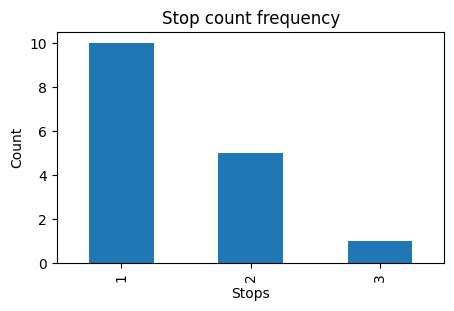

,count
sequence_short,
M-H,7
H-M,3
H-M-H,3
H-H-M,1
H-M-H-S,1
M-H-S,1


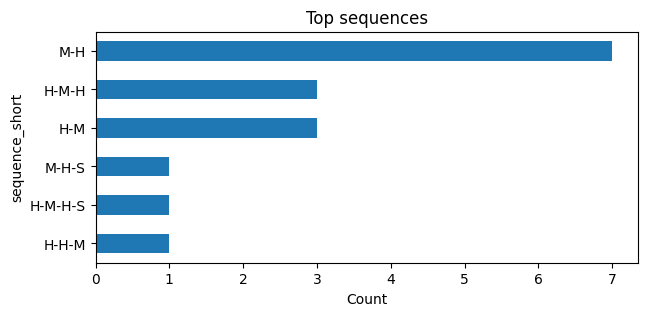

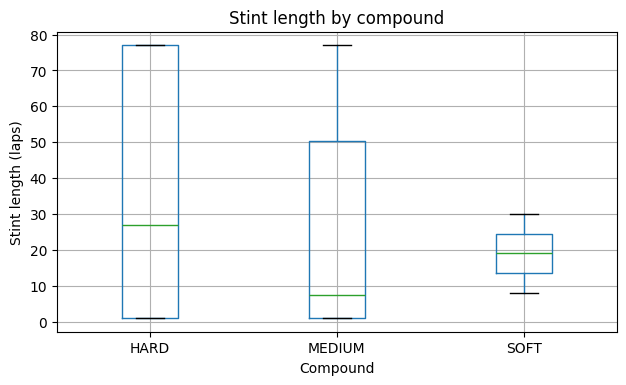

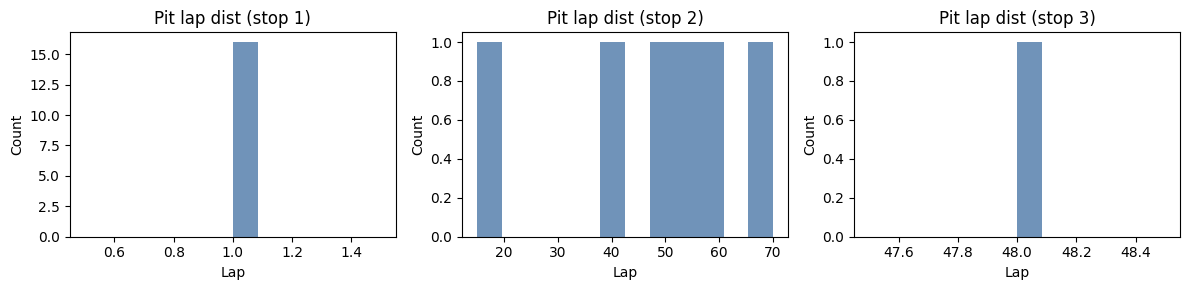

,driver_id,stop_count,sequence_short,pit_laps,stint_lens
2341,ALB,1,M-H,[1],"[1, 77]"
2342,ALO,1,H-M,[1],"[1, 77]"
2343,BOT,2,H-M-H,"[1, 15]","[1, 14, 63]"
2344,GAS,1,H-M,[1],"[1, 77]"
2345,HAM,2,H-M-H,"[1, 51]","[1, 50, 27]"
2346,LEC,1,M-H,[1],"[1, 77]"
2347,NOR,1,M-H,[1],"[1, 77]"
2348,PIA,1,M-H,[1],"[1, 77]"
2349,RIC,1,M-H,[1],"[1, 77]"
2350,RUS,1,H-M,[1],"[1, 77]"


In [19]:

if not strategies_df.empty:
    top_pair = (
        strategies_df.groupby(['circuit_id', 'year']).size()
        .sort_values(ascending=False)
        .index[0]
    )
    show_circuit_year("monaco", 2024)


In [20]:

joblib.dump(library, EXPORT_PATH)
print('Saved library to', EXPORT_PATH)


Saved library to /Users/ekazuki/Documents/f1stuff/models/models/strategy_library.joblib


In [21]:

# Debug a specific driver/session
DEBUG_YEAR = 2025
DEBUG_EVENT = 'Monaco'
DEBUG_SESSION = 'Race'
DEBUG_DRIVER = 'ANT'

debug_session = ff1.get_session(DEBUG_YEAR, DEBUG_EVENT, DEBUG_SESSION)
debug_session.load(laps=True, telemetry=False, weather=False, messages=False)

debug_laps = debug_session.laps.copy()
if USE_ACCURATE_LAPS and 'IsAccurate' in debug_laps.columns:
    debug_laps = debug_laps[debug_laps['IsAccurate'] == True]

print('LapNumber range:', debug_laps['LapNumber'].min(), '-', debug_laps['LapNumber'].max())
print('Missing laps (first 20):', sorted(set(range(1, int(debug_session.total_laps or debug_laps['LapNumber'].max()) + 1)) - set(debug_laps['LapNumber'].dropna().astype(int)))[:20])


print('Total laps:', debug_session.total_laps)
print('Drivers:', debug_session.drivers)

debug_driver = debug_laps[debug_laps['Driver'] == DEBUG_DRIVER].copy()
display(debug_driver[['LapNumber', 'Stint', 'Compound', 'TyreLife', 'PitInTime', 'PitOutTime', 'IsAccurate']].head(60))
print('PitIn laps:', debug_driver.loc[debug_driver['PitInTime'].notna(), 'LapNumber'].astype(int).tolist() if 'PitInTime' in debug_driver.columns else [])
print('PitOut laps:', debug_driver.loc[debug_driver['PitOutTime'].notna(), 'LapNumber'].astype(int).tolist() if 'PitOutTime' in debug_driver.columns else [])

print('Compound counts per stint (including NaN):')
display(
    debug_driver.groupby('Stint')['Compound']
    .value_counts(dropna=False)
    .rename('count')
    .reset_index()
)

print('Stint lap ranges:')
display(
    debug_driver.groupby('Stint')['LapNumber']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print('Derived stints (build_driver_stints):')
display(build_driver_stints(debug_laps, DEBUG_DRIVER))


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
Request for URL https://api.jolpi.ca/ergast/f1/2025/8/results.json failed; using cached response
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests_cache/session.py", line 291, in _resend
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/8/results.json
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_s

LapNumber range: 1.0 - 78.0
Missing laps (first 20): []
Total laps: 78
Drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


,LapNumber,Stint,Compound,TyreLife,PitInTime,PitOutTime,IsAccurate
86,1.0,1.0,HARD,1.0,NaT,NaT,False
87,2.0,1.0,HARD,2.0,NaT,NaT,False
88,3.0,1.0,HARD,3.0,NaT,NaT,False
89,4.0,1.0,HARD,4.0,NaT,NaT,False
90,5.0,1.0,HARD,5.0,NaT,NaT,True
91,6.0,1.0,HARD,6.0,NaT,NaT,True
92,7.0,1.0,HARD,7.0,NaT,NaT,True
93,8.0,1.0,HARD,8.0,NaT,NaT,True
94,9.0,1.0,HARD,9.0,NaT,NaT,True
95,10.0,1.0,HARD,10.0,NaT,NaT,True


PitIn laps: [69, 71]
PitOut laps: [70, 72]
Compound counts per stint (including NaN):


,Stint,Compound,count
0,1.0,HARD,69
1,2.0,MEDIUM,2
2,3.0,HARD,4


Stint lap ranges:


,Stint,min,max,count
0,1.0,1.0,69.0,69
1,2.0,70.0,71.0,2
2,3.0,72.0,75.0,4


Derived stints (build_driver_stints):


{'sequence': ['HARD', 'MEDIUM', 'HARD'],
 'sequence_key': 'HARD-MEDIUM-HARD',
 'sequence_short': 'H-M-H',
 'stint_lens': [69, 2, 4],
 'pit_laps': [69, 71],
 'stop_count': 2,
 'max_lap': 75}